# 09_MHCprop_Age_Correlation
## Xiaonan Wang
## 18Sep2026

In [1]:
#%matplotlib nbagg
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc
import pandas as pd
from os import listdir
from os.path import isfile, join
import re
import anndata
# import scvi

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

sc.settings.verbosity = 3  # verbosity: errors (0), warnings (1), info (2), hints (3)

from matplotlib.colors import LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list(name='gene_cmap', colors=['lightgrey', '#a1a1ce', 'purple', '#301934']) 
sc.settings.set_figure_params(dpi=80, color_map='viridis', vector_friendly=False,  dpi_save=300)

In [2]:
import sys

project_dir = "/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Data/External_Data/Xu_NC2026_human/analysis_v1"

if project_dir not in sys.path:
    sys.path.append(project_dir)

import source

In [3]:
sc.logging.print_header()

Package,Version
numpy,2.4.5
matplotlib,3.10.9
scanpy,1.11.5
pandas,2.3.3
anndata,0.12.14
Component,Info
Python,"3.11.6 | packaged by conda-forge | (main, Oct 3 2023, 10:40:35) [GCC 12.3.0]"
OS,Linux-4.18.0-553.81.1.el8_10.x86_64-x86_64-with-glibc2.28
CPU,"5/64 logical CPU cores, x86_64"
GPU,No GPU found


In [3]:
datadir = "/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Data/External_Data/Xu_NC2026_human/data/Spatial/"
outdir = "/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Data/External_Data/Xu_NC2026_human/analysis_v1/write_all/"

In [4]:
x_all = sc.read_h5ad(datadir + "all_updated.h5ad")

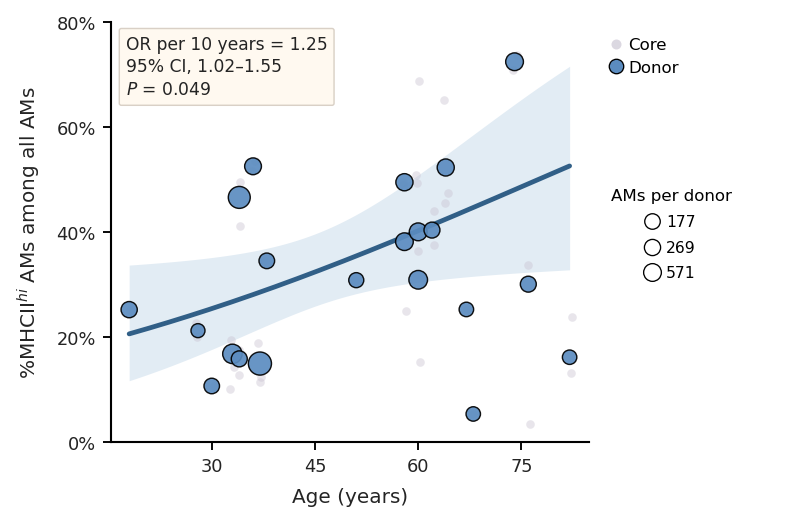

In [10]:
# For Tissue A
age_result_A = plot_mhcii_hi_proportion_by_age(
    adata=x_all,
    group_col="MHCII_group",
    hi_label="MHCIIhi",
    donor_col="donor_id",
    core_col="core_id",
    age_col="age",
    tissue_col="tissue_annotation",
    tissue="A",
    celltype_col="CellType_refined",
    am_labels=("AM", "Alveolar Macrophage"),
    min_am_per_core=10,
    min_am_per_donor=30,
    output_file=(
        "MHCIIhi_AM_proportion_by_age_"
        "tissueA.pdf"
    ),
    dpi=300,
)

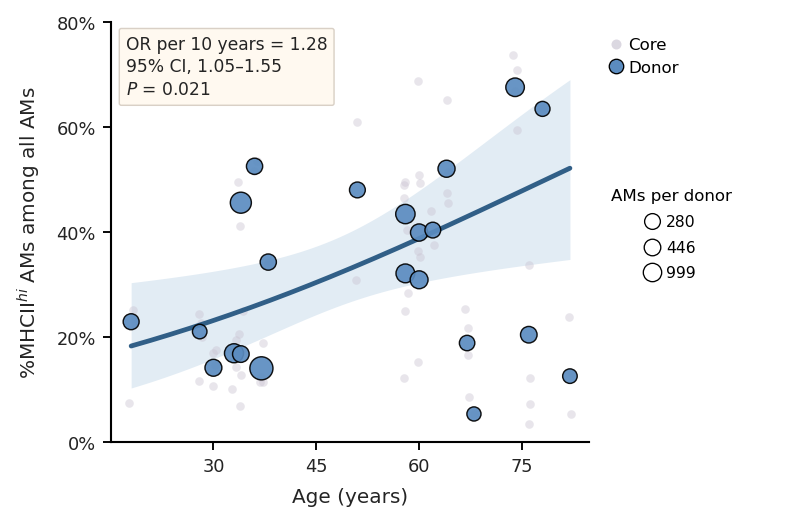

In [11]:
# All Tissues
age_result_all = plot_mhcii_hi_proportion_by_age(
    adata=x_all,
    group_col="MHCII_group",
    tissue=None,
    min_am_per_core=10,
    min_am_per_donor=30,
    output_file="MHCIIhi_AM_proportion_by_age_all_tissues.pdf",
)